# 04 — Resultados y análisis final

Este notebook reúne los resultados computacionales de **Al, Nb y Pb** y los compara con los valores de \(\Delta(0)\) obtenidos de la literatura.

> **Importante:** Hg y Ta pueden permanecer en la tabla bibliográfica, pero no se incluyen en el análisis computacional mientras no se disponga de sus tres CSV.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT=Path.cwd().resolve()
if ROOT.name=="notebooks": ROOT=ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
TABLES=ROOT/"results"/"tables"; FIGS=ROOT/"results"/"figures"
TABLES.mkdir(parents=True,exist_ok=True); FIGS.mkdir(parents=True,exist_ok=True)
COMPUTATIONAL_MATERIALS=["Al","Nb","Pb"]


## 1. Valores bibliográficos

La guía solicita \(T_c\) y \(\Delta(0)\) para Al, Hg, Nb, Ta y Pb. En esta celda se dejan los campos de \(\Delta(0)\) preparados para incorporar **la fuente bibliográfica concreta** utilizada en el informe.

In [2]:
# ============================================================
# DATOS EXPERIMENTALES / LITERATURA
# ============================================================

literature = {

    "Al": {
        "Tc_K": 1.18,
        "Delta0_meV": 0.170,
        "source": (
            "Tai et al., Advanced Quantum Technologies (2024), "
            "doi:10.1002/qute.202200145"
        ),
    },

    "Hg": {
        "Tc_K": 4.15,
        "Delta0_meV": 0.825,
        "source": (
            "Engineering Physics, Table 9.4: "
            "Energy gap at 0 K for some superconductors"
        ),
    },

    "Nb": {
        "Tc_K": 9.25,
        "Delta0_meV": 1.55,
        "source": (
            "Finnemore et al., Physical Review 149, 231 (1966); "
            "Frontiers in Physics (2023)"
        ),
    },

    "Ta": {
        "Tc_K": 4.48,
        "Delta0_meV": 0.664,
        "source": (
            "Superconducting tunnel junctions as detectors "
            "for ultraviolet, optical, and near infrared astronomy"
        ),
    },

    "Pb": {
        "Tc_K": 7.19,
        "Delta0_meV": 1.45,
        "source": (
            "Engineering Physics, Table 9.4: "
            "Energy gap at 0 K for some superconductors"
        ),
    },
}

# Convertir el diccionario a DataFrame
literature = pd.DataFrame(
    [
        {
            "material": material,
            "Tc_K": data["Tc_K"],
            "Delta0_meV": data["Delta0_meV"],
            "source": data["source"],
        }
        for material, data in literature.items()
    ]
)

display(literature)

,material,Tc_K,Delta0_meV,source
0,Al,1.18,0.170,"Tai et al., Advanced Quantum Technologies (202..."
1,Hg,4.15,0.825,"Engineering Physics, Table 9.4: Energy gap at ..."
2,Nb,9.25,1.550,"Finnemore et al., Physical Review 149, 231 (19..."
3,Ta,4.48,0.664,Superconducting tunnel junctions as detectors ...
4,Pb,7.19,1.450,"Engineering Physics, Table 9.4: Energy gap at ..."


## 2. Carga de resultados computacionales

El notebook 03 genera un resumen conjunto `eDcp_resumen.csv`. También se aceptan archivos individuales `*_eDcp_resumen.csv` para mantener compatibilidad con ejecuciones anteriores.

In [3]:
candidates=[TABLES/"eDcp_resumen.csv"]+sorted(TABLES.glob("*_eDcp_resumen.csv"))
existing=[p for p in candidates if p.exists()]
if not existing: raise FileNotFoundError("Ejecuta primero 03_calculo_eDcp.ipynb.")
frames=[pd.read_csv(p) for p in existing]
results=pd.concat(frames,ignore_index=True).drop_duplicates(subset=["material"],keep="last")
results=results[results["material"].isin(COMPUTATIONAL_MATERIALS)].copy()
results

,material,Tc_K,omega_c_meV,omega_epsilon_meV,omega_epsilon_prime_meV,Delta_Dcp_meV,half_Delta_Dcp_meV
0,Al,1.18,39.676242,0.165456,-0.165456,0.330911,0.165456
1,Nb,9.25,26.248375,0.941351,-0.941351,1.882702,0.941351
2,Pb,7.19,9.870604,1.045510,-1.061975,2.107485,1.053743


## 3. Tabla principal

In [4]:
# ============================================================
# COMPARACIÓN: CÁLCULO vs LITERATURA
# ============================================================

analysis = results.merge(
    literature,
    on="material",
    how="left",
    suffixes=("_calc", "_lit")
)

# ============================================================
# Delta_Dcp / 2
# ============================================================

analysis["half_Delta_Dcp_meV"] = (
    analysis["Delta_Dcp_meV"].abs() / 2.0
)

# ============================================================
# Relación:
#
# (1/2 Delta_Dcp) / Delta(0)
# ============================================================

analysis["ratio_halfDcp_Delta0"] = (
    analysis["half_Delta_Dcp_meV"]
    / analysis["Delta0_meV"]
)

# ============================================================
# Error absoluto
# ============================================================

analysis["error_abs_meV"] = (
    analysis["half_Delta_Dcp_meV"]
    - analysis["Delta0_meV"]
).abs()

# ============================================================
# Error porcentual
# ============================================================

analysis["error_percent"] = (
    100.0
    * analysis["error_abs_meV"]
    / analysis["Delta0_meV"]
)

# ============================================================
# COLUMNAS FINALES
# ============================================================

cols = [
    "material",
    "Tc_K_lit",
    "omega_c_meV",
    "omega_epsilon_meV",
    "omega_epsilon_prime_meV",
    "Delta_Dcp_meV",
    "half_Delta_Dcp_meV",
    "Delta0_meV",
    "ratio_halfDcp_Delta0",
    "error_abs_meV",
    "error_percent",
    "source",
]

display(
    analysis[cols]
)

,material,Tc_K_lit,omega_c_meV,omega_epsilon_meV,omega_epsilon_prime_meV,Delta_Dcp_meV,half_Delta_Dcp_meV,Delta0_meV,ratio_halfDcp_Delta0,error_abs_meV,error_percent,source
0,Al,1.18,39.676242,0.165456,-0.165456,0.330911,0.165456,0.17,0.973268,0.004544,2.673204,"Tai et al., Advanced Quantum Technologies (202..."
1,Nb,9.25,26.248375,0.941351,-0.941351,1.882702,0.941351,1.55,0.607323,0.608649,39.267662,"Finnemore et al., Physical Review 149, 231 (19..."
2,Pb,7.19,9.870604,1.045510,-1.061975,2.107485,1.053743,1.45,0.726719,0.396257,27.328102,"Engineering Physics, Table 9.4: Energy gap at ..."


## 4. Comparación \(\Delta(0)\) vs. \(\frac12\Delta_{Dcp}\)

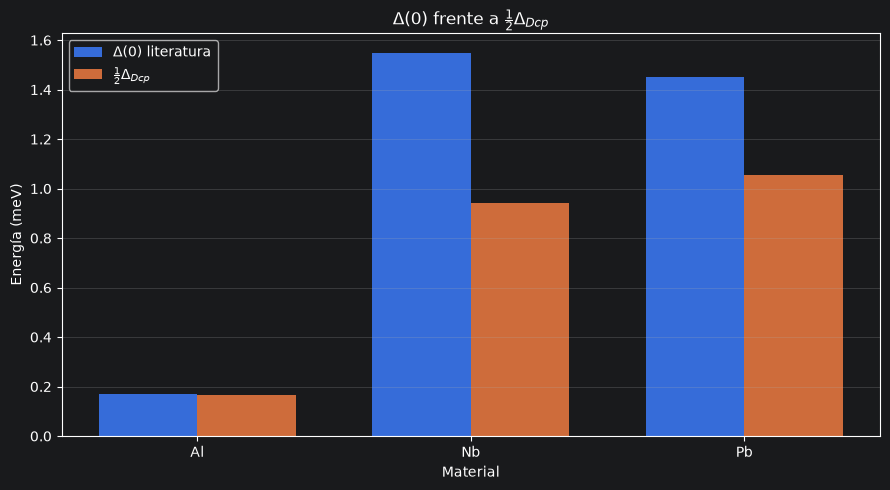

In [5]:
valid=analysis.dropna(subset=["Delta0_meV","half_Delta_Dcp_meV"]).copy()
if len(valid):
    x=np.arange(len(valid)); width=.36
    fig,ax=plt.subplots(figsize=(9,5)); ax.bar(x-width/2,valid["Delta0_meV"],width,label=r"$\Delta(0)$ literatura"); ax.bar(x+width/2,valid["half_Delta_Dcp_meV"],width,label=r"$\frac{1}{2}\Delta_{Dcp}$"); ax.set_xticks(x); ax.set_xticklabels(valid["material"]); ax.set_ylabel("Energía (meV)"); ax.set_xlabel("Material"); ax.set_title(r"$\Delta(0)$ frente a $\frac{1}{2}\Delta_{Dcp}$"); ax.grid(axis="y",alpha=.3); ax.legend(); fig.tight_layout(); fig.savefig(FIGS/"comparacion_Delta0_half_DeltaDcp.png",dpi=300); plt.show()
else: print("Completa Delta0_meV y source para generar la comparación.")

## 5. Análisis cuantitativo

Con al menos dos materiales con \(\Delta(0)\) disponible se calcula un ajuste lineal y \(R^2\). Esto permite evaluar una posible tendencia sin afirmar una relación universal de forma prematura.

Pendiente = 0.618246
Intercepto = 0.066903 meV
r = 0.983580
R² = 0.967429


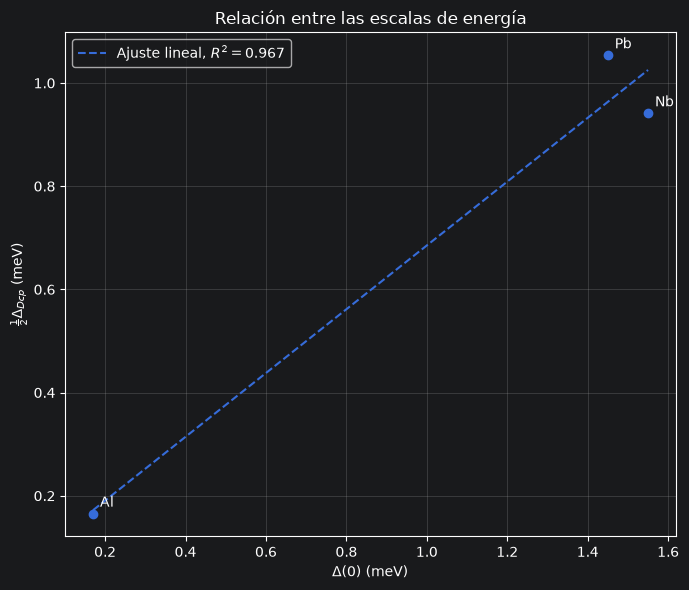

In [6]:
if len(valid)>=2:
    x=valid["Delta0_meV"].to_numpy(float); y=valid["half_Delta_Dcp_meV"].to_numpy(float)
    slope,intercept=np.polyfit(x,y,1); yfit=slope*x+intercept
    ss_res=np.sum((y-yfit)**2); ss_tot=np.sum((y-y.mean())**2); r2=1-ss_res/ss_tot if ss_tot>0 else np.nan; r=np.corrcoef(x,y)[0,1]
    print(f"Pendiente = {slope:.6f}"); print(f"Intercepto = {intercept:.6f} meV"); print(f"r = {r:.6f}"); print(f"R² = {r2:.6f}")
    fig,ax=plt.subplots(figsize=(7,6)); ax.scatter(x,y); xx=np.linspace(x.min(),x.max(),200); ax.plot(xx,slope*xx+intercept,ls="--",label=fr"Ajuste lineal, $R^2={r2:.3f}$")
    for _,row in valid.iterrows(): ax.annotate(row["material"],(row["Delta0_meV"],row["half_Delta_Dcp_meV"]),xytext=(5,5),textcoords="offset points")
    ax.set(xlabel=r"$\Delta(0)$ (meV)",ylabel=r"$\frac{1}{2}\Delta_{Dcp}$ (meV)",title="Relación entre las escalas de energía"); ax.grid(alpha=.3); ax.legend(); fig.tight_layout(); fig.savefig(FIGS/"relacion_Delta0_half_DeltaDcp.png",dpi=300); plt.show()
else: print("Se requieren al menos dos materiales con Delta(0) bibliográfico para el ajuste.")

## 6. Tabla final y exportación

In [7]:
final=analysis[["material","Tc_K_lit","omega_c_meV","omega_epsilon_meV","omega_epsilon_prime_meV","Delta_Dcp_meV","half_Delta_Dcp_meV","Delta0_meV","ratio_halfDcp_Delta0"]].copy()
final.columns=["Material","Tc (K)","ωc (meV)","ωε (meV)","ωε' (meV)","ΔDcp (meV)","½ΔDcp (meV)","Δ(0) (meV)","(½ΔDcp)/Δ(0)"]
display(final)
final.to_csv(TABLES/"tabla_resultados_finales.csv",index=False)
print("Guardado:",TABLES/"tabla_resultados_finales.csv")

,Material,Tc (K),ωc (meV),ωε (meV),ωε' (meV),ΔDcp (meV),½ΔDcp (meV),Δ(0) (meV),(½ΔDcp)/Δ(0)
0,Al,1.18,39.676242,0.165456,-0.165456,0.330911,0.165456,0.17,0.973268
1,Nb,9.25,26.248375,0.941351,-0.941351,1.882702,0.941351,1.55,0.607323
2,Pb,7.19,9.870604,1.045510,-1.061975,2.107485,1.053743,1.45,0.726719


Guardado: /home/monroy/Documentos/Cooper_pair_distribution/results/tables/tabla_resultados_finales.csv


## 7. Conclusión

La conclusión debe distinguir claramente entre **tendencia estadística** y **relación matemática**. Con solo tres materiales computacionales (Al, Nb y Pb), el análisis puede mostrar una tendencia, pero no debe presentarse como una ley universal sin evidencia adicional.